In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
os.makedirs('LR/models', exist_ok=True)

In [2]:
import pandas as pd
import joblib
import os

# ==========================================
# 📥 1. โหลดข้อมูลและตัวแปรที่คัดมาแล้ว
# ==========================================

# 1.1 ใส่ Path ข้อมูลของตัวเอง (แก้ path ให้ตรงกับเครื่องตัวเองนะคะ)
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดข้อมูล X_train, y_train, X_test, y_test เข้ามา
# (สมมติว่าตัวเองมีไฟล์ test แยกไว้แล้ว ถ้าไม่มีก็โหลดตัวเต็มมา split ใหม่ได้ค่ะ)
X_train_full = pd.read_csv(f'{path}X_train_90.csv')
y_train = pd.read_csv(f'{path}y_train_90.csv').squeeze() # .squeeze() เพื่อให้เป็น Series
X_test_full = pd.read_csv(f'{path}X_test_10.csv')      # ถ้าชื่อไฟล์ test ไม่ตรง แก้ได้เลยนะคะ
y_test = pd.read_csv(f'{path}y_test_10.csv').squeeze()

# -------------------------------------------------------
# 🔥 ไฮไลท์: โหลด "10 ตัวเทพ" ที่ RFE เลือกไว้มาใช้
# -------------------------------------------------------
# ต้องมั่นใจว่าไฟล์ pkl อยู่ในโฟลเดอร์ models หรือ path เดียวกัน
selected_features = joblib.load('models/rfe_lr_features.pkl')

print(f"✅ โหลดตัวแปรที่คัดเลือกมาแล้ว {len(selected_features)} ตัว:")
print(selected_features)

# 1.2 กรองข้อมูลให้เหลือแค่ 10 ตัวนี้
X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print("\n------------------------------------------------")
print(f"Shape ข้อมูลพร้อมเทรน:")
print(f"X_train: {X_train.shape}  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10")
print(f"X_test:  {X_test.shape}")
print("------------------------------------------------")

✅ โหลดตัวแปรที่คัดเลือกมาแล้ว 10 ตัว:
['Age', 'Gender', 'Smoking', 'BMI', 'High LDL Cholesterol', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Fasting Blood Sugar', 'Homocysteine Level']

------------------------------------------------
Shape ข้อมูลพร้อมเทรน:
X_train: (9000, 10)  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10
X_test:  (1000, 10)
------------------------------------------------


------------------------------
Logistic Regression - Baseline (No Sampling)
------------------------------
Start Cross-Validation...
------------------------------
Fold 1: Val Accuracy = 0.8000
Fold 2: Val Accuracy = 0.8000
Fold 3: Val Accuracy = 0.8000
Fold 4: Val Accuracy = 0.8000
Fold 5: Val Accuracy = 0.8000
------------------------------
>> Average CV Accuracy: 0.8000 (± 0.0000)
>> 🏆 Best Model Found in Fold: 1
------------------------------

TEST PERFORMANCE (LR Baseline - Fold 1)
Accuracy:  0.8000
Recall:    0.0000
ROC-AUC:   0.4911


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


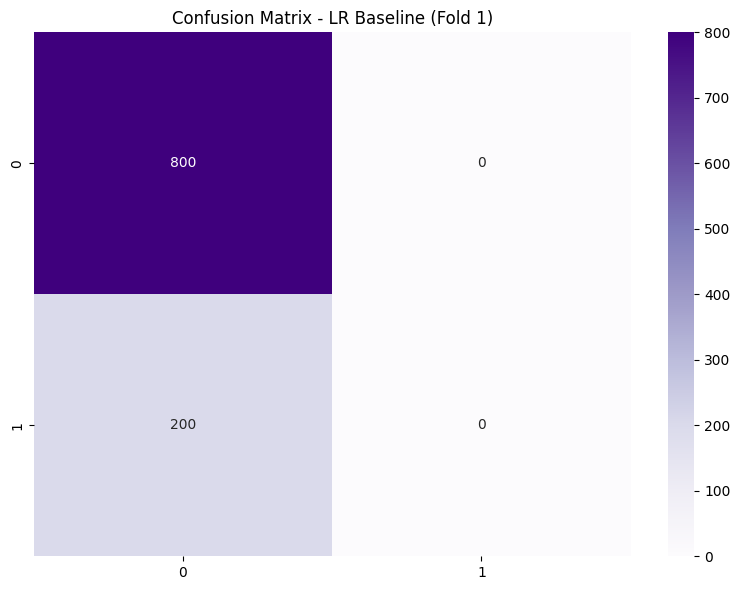

✓ Saved Best Model: logistic_regression/models/LR_baseline_bestfold.pkl


In [3]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่า (LR - Baseline)
# ==========================================
print("-" * 30)
print('Logistic Regression - Baseline (No Sampling)')
print("-" * 30)

best_model_lr_base = None
best_score_lr_base = 0
best_fold_idx_lr_base = -1

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 สร้างโมเดล Logistic Regression
    # max_iter=2000 เพื่อกัน Error เวลาข้อมูลยังไม่ Scale
    # solver='liblinear' เหมาะกับ Binary Classification
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train, y_fold_train)
    
    # 2.3 สอบย่อย
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    # 2.4 คัดเลือกผู้ชนะ
    if score > best_score_lr_base:
        best_score_lr_base = score
        best_model_lr_base = model
        best_fold_idx_lr_base = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_base}')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set)
# ==========================================
y_pred = best_model_lr_base.predict(X_test)
y_pred_proba = best_model_lr_base.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR Baseline - Fold {best_fold_idx_lr_base})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR Baseline (Fold {best_fold_idx_lr_base})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_baseline.png', dpi=300)
plt.show()

lr_baseline_results = {
    'Model': 'Logistic Regression',
    'Sampling': 'None (Baseline)',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

joblib.dump(best_model_lr_base, 'logistic_regression/models/LR_baseline_bestfold.pkl')
print(f"✓ Saved Best Model: logistic_regression/models/LR_baseline_bestfold.pkl")

------------------------------
Logistic Regression + SMOTE (Pick Best Fold)
------------------------------
Fold 1: Val Accuracy = 0.5211
Fold 2: Val Accuracy = 0.5172
Fold 3: Val Accuracy = 0.5189
Fold 4: Val Accuracy = 0.5122
Fold 5: Val Accuracy = 0.5133
------------------------------
>> Average CV Accuracy: 0.5166
>> 🏆 Best Model Found in Fold: 1

TEST PERFORMANCE (LR + SMOTE)
Recall: 0.4650
ROC-AUC: 0.4868


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

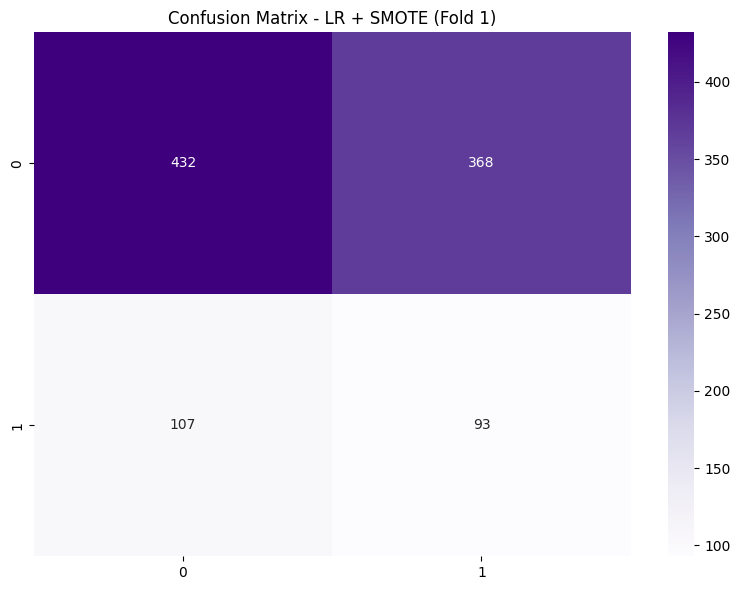

✓ Saved Best Model: logistic_regression/models/LR_smote_bestfold.pkl


In [4]:
from imblearn.over_sampling import SMOTE
# from imblearn.over_sampling import ADASYN
# from imblearn.under_sampling import NearMiss

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่า (LR + SMOTE)
# ==========================================
print("-" * 30)
print('Logistic Regression + SMOTE (Pick Best Fold)')
print("-" * 30)

best_model_lr_smote = None
best_score_lr_smote = 0
best_fold_idx_lr_smote = -1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ Sampling (เปลี่ยนตัวได้ตรงนี้!)
    sampler = SMOTE(random_state=42)
    X_fold_train_res, y_fold_train_res = sampler.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดล LR
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    # 2.4 Validate
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_smote:
        best_score_lr_smote = score
        best_model_lr_smote = model
        best_fold_idx_lr_smote = fold

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f}')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_smote}')

# ==========================================
# 📊 ส่วนที่ 3: Test Evaluation
# ==========================================
y_pred = best_model_lr_smote.predict(X_test)
y_pred_proba = best_model_lr_smote.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + SMOTE)")
print(f"Recall: {test_recall:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")

# ==========================================
# 🎨 ส่วนที่ 4: Save Results
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + SMOTE (Fold {best_fold_idx_lr_smote})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_smote.png', dpi=300)
plt.show()

lr_smote_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'SMOTE (Fold {best_fold_idx_lr_smote})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

joblib.dump(best_model_lr_smote, 'logistic_regression/models/LR_smote_bestfold.pkl')
print(f"✓ Saved Best Model: logistic_regression/models/LR_smote_bestfold.pkl")

------------------------------
LR + ADASYN (Pick Best Fold)
------------------------------
Fold 1: Val Accuracy = 0.4939
Fold 2: Val Accuracy = 0.4806


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 3: Val Accuracy = 0.5139
Fold 4: Val Accuracy = 0.4939
Fold 5: Val Accuracy = 0.5089
------------------------------
>> Average CV Accuracy: 0.4982 (± 0.0119)
>> 🏆 Best Model Found in Fold: 3
------------------------------

TEST PERFORMANCE (LR + ADASYN - Fold 3)
Accuracy:  0.5120
Recall:    0.4900
ROC-AUC:   0.4939


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


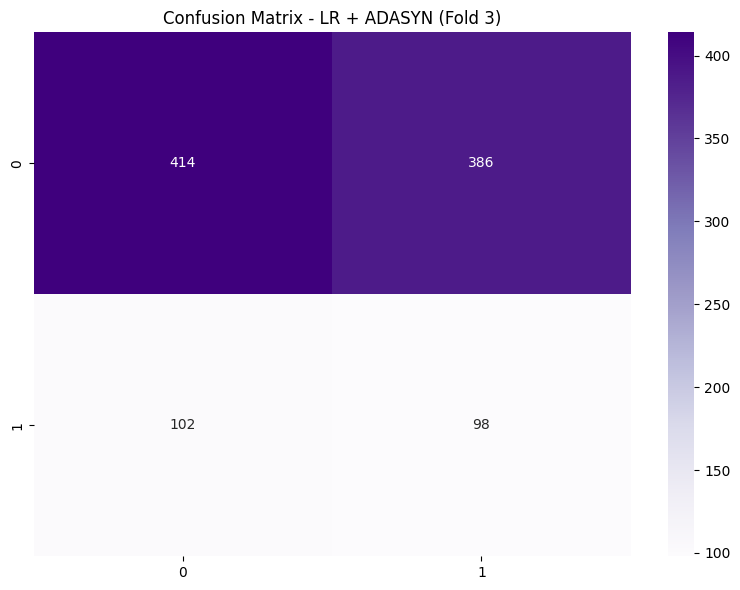

✓ Done: ADASYN


In [5]:
from imblearn.over_sampling import ADASYN
from sklearn.linear_model import LogisticRegression

print("-" * 30)
print('LR + ADASYN (Pick Best Fold)')
print("-" * 30)

best_model_lr_adasyn = None
best_score_lr_adasyn = 0
best_fold_idx_lr_adasyn = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]

    # ADASYN
    adasyn = ADASYN(random_state=42)
    X_fold_train_res, y_fold_train_res = adasyn.fit_resample(X_fold_train, y_fold_train)

    # Model
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)

    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")

    if score > best_score_lr_adasyn:
        best_score_lr_adasyn = score
        best_model_lr_adasyn = model
        best_fold_idx_lr_adasyn = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_adasyn}')
print("-" * 30)

# Test Evaluation
y_pred = best_model_lr_adasyn.predict(X_test)
y_pred_proba = best_model_lr_adasyn.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + ADASYN - Fold {best_fold_idx_lr_adasyn})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + ADASYN (Fold {best_fold_idx_lr_adasyn})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_adasyn.png', dpi=300)
plt.show()

lr_adasyn_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'ADASYN (Fold {best_fold_idx_lr_adasyn})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_adasyn, 'logistic_regression/models/LR_adasyn_bestfold.pkl')
print("✓ Done: ADASYN")

------------------------------
LR + RandomUnderSampler
------------------------------
Fold 1: Val Accuracy = 0.4972
Fold 2: Val Accuracy = 0.5122
Fold 3: Val Accuracy = 0.5106
Fold 4: Val Accuracy = 0.5089
Fold 5: Val Accuracy = 0.4967
------------------------------
>> Average CV Accuracy: 0.5051 (± 0.0068)
>> 🏆 Best Model Found in Fold: 2
------------------------------

TEST PERFORMANCE (LR + RandomUnderSampler - Fold 2)
Accuracy:  0.4940
Recall:    0.4850
ROC-AUC:   0.4790


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._

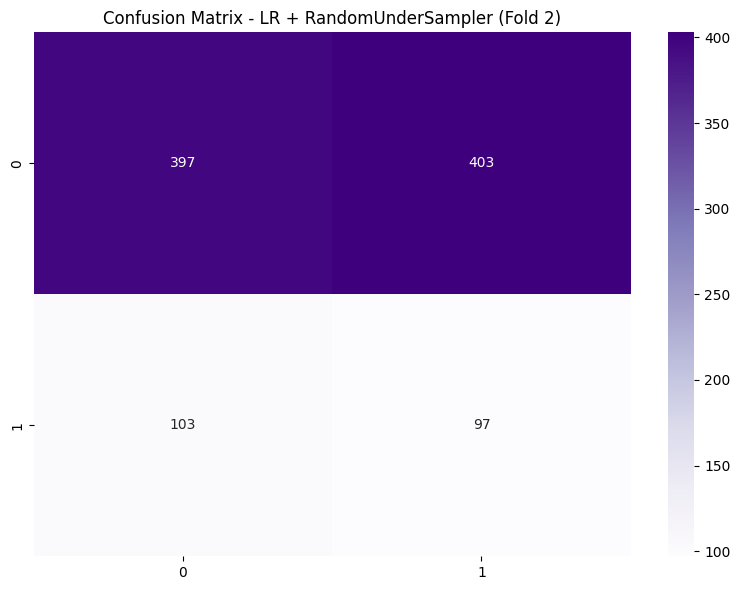

✓ Done: RandomUnderSampler


In [6]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('LR + RandomUnderSampler')
print("-" * 30)

best_model_lr_rus = None
best_score_lr_rus = 0
best_fold_idx_lr_rus = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # RandomUnderSampler
    rus = RandomUnderSampler(random_state=42)
    X_fold_train_res, y_fold_train_res = rus.fit_resample(X_fold_train, y_fold_train)
    
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_rus:
        best_score_lr_rus = score
        best_model_lr_rus = model
        best_fold_idx_lr_rus = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_rus}')
print("-" * 30)

y_pred = best_model_lr_rus.predict(X_test)
y_pred_proba = best_model_lr_rus.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + RandomUnderSampler - Fold {best_fold_idx_lr_rus})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + RandomUnderSampler (Fold {best_fold_idx_lr_rus})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_rus.png', dpi=300)
plt.show()

lr_rus_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'RandomUnderSampler (Fold {best_fold_idx_lr_rus})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_rus, 'logistic_regression/models/LR_rus_bestfold.pkl')
print("✓ Done: RandomUnderSampler")

------------------------------
LR + NearMiss
------------------------------
Fold 1: Val Accuracy = 0.4750
Fold 2: Val Accuracy = 0.5111


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 3: Val Accuracy = 0.4800
Fold 4: Val Accuracy = 0.4889
Fold 5: Val Accuracy = 0.5072
------------------------------
>> Average CV Accuracy: 0.4924 (± 0.0144)
>> 🏆 Best Model Found in Fold: 2
------------------------------

TEST PERFORMANCE (LR + NearMiss - Fold 2)
Accuracy:  0.4930
Recall:    0.5600
ROC-AUC:   0.5283


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


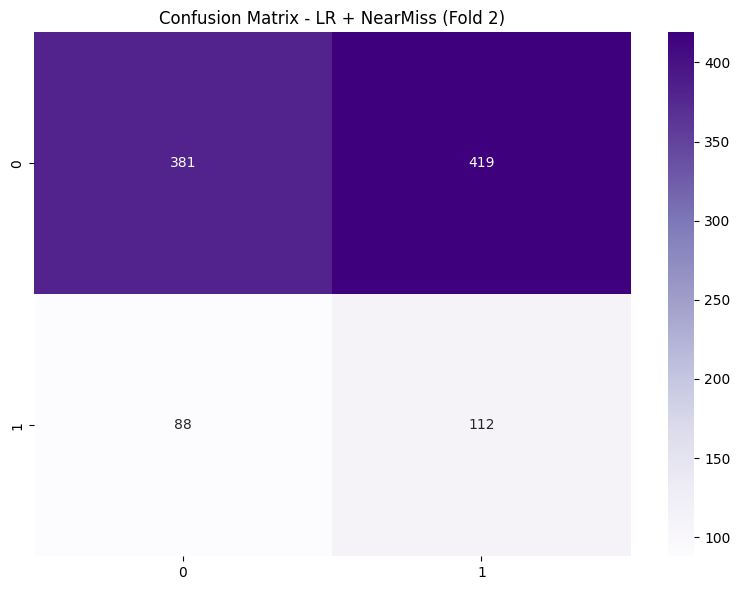

✓ Done: NearMiss


In [7]:
from imblearn.under_sampling import NearMiss

print("-" * 30)
print('LR + NearMiss')
print("-" * 30)

best_model_lr_nm = None
best_score_lr_nm = 0
best_fold_idx_lr_nm = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # NearMiss
    nm = NearMiss(version=1)
    X_fold_train_res, y_fold_train_res = nm.fit_resample(X_fold_train, y_fold_train)
    
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_nm:
        best_score_lr_nm = score
        best_model_lr_nm = model
        best_fold_idx_lr_nm = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_nm}')
print("-" * 30)

y_pred = best_model_lr_nm.predict(X_test)
y_pred_proba = best_model_lr_nm.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + NearMiss - Fold {best_fold_idx_lr_nm})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + NearMiss (Fold {best_fold_idx_lr_nm})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_nearmiss.png', dpi=300)
plt.show()

lr_nearmiss_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'NearMiss (Fold {best_fold_idx_lr_nm})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_nm, 'logistic_regression/models/LR_nearmiss_bestfold.pkl')
print("✓ Done: NearMiss")

------------------------------
LR + ClusterCentroids
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.5061


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5156


...

Fold 3: Val Accuracy = 0.5117


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5011


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.5150
------------------------------
>> Average CV Accuracy: 0.5099 (± 0.0055)
>> 🏆 Best Model Found in Fold: 2
------------------------------

TEST PERFORMANCE (LR + ClusterCentroids - Fold 2)
Accuracy:  0.5250
Recall:    0.4600
ROC-AUC:   0.4943


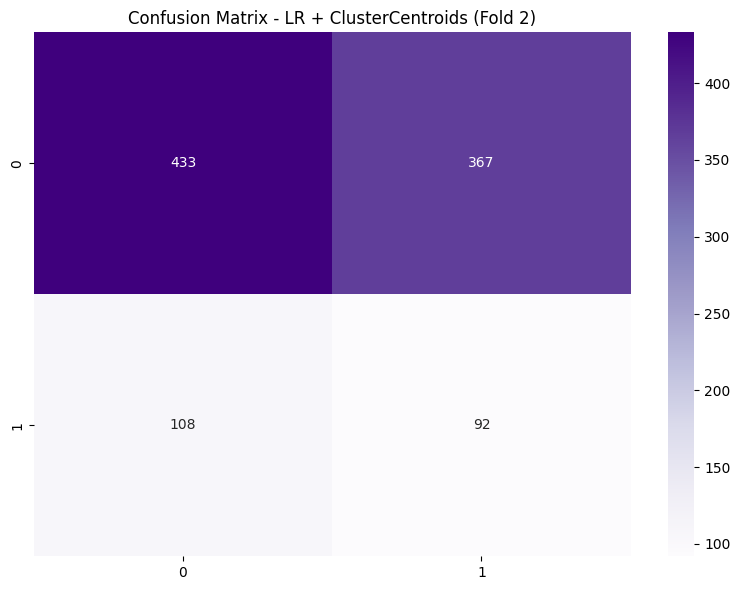

✓ Done: ClusterCentroids


In [8]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('LR + ClusterCentroids')
print("-" * 30)

best_model_lr_cc = None
best_score_lr_cc = 0
best_fold_idx_lr_cc = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # ClusterCentroids
    cc = ClusterCentroids(random_state=42)
    X_fold_train_res, y_fold_train_res = cc.fit_resample(X_fold_train, y_fold_train)
    
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_cc:
        best_score_lr_cc = score
        best_model_lr_cc = model
        best_fold_idx_lr_cc = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_cc}')
print("-" * 30)

y_pred = best_model_lr_cc.predict(X_test)
y_pred_proba = best_model_lr_cc.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + ClusterCentroids - Fold {best_fold_idx_lr_cc})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + ClusterCentroids (Fold {best_fold_idx_lr_cc})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_cc.png', dpi=300)
plt.show()

lr_cc_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'ClusterCentroids (Fold {best_fold_idx_lr_cc})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_cc, 'logistic_regression/models/LR_cc_bestfold.pkl')
print("✓ Done: ClusterCentroids")

------------------------------
LR + SMOTETomek
------------------------------


Fold 1: Val Accuracy = 0.5194


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.5183


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 3: Val Accuracy = 0.5228


Fold 4: Val Accuracy = 0.5128


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.5150
------------------------------
>> Average CV Accuracy: 0.5177 (± 0.0035)
>> 🏆 Best Model Found in Fold: 3
------------------------------

TEST PERFORMANCE (LR + SMOTETomek - Fold 3)
Accuracy:  0.5310
Recall:    0.4700
ROC-AUC:   0.4986


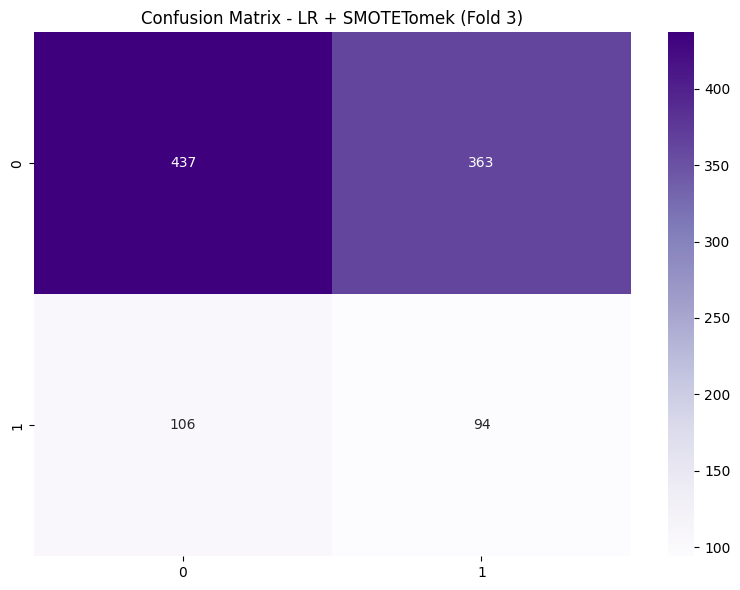

✓ Done: SMOTETomek


In [9]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('LR + SMOTETomek')
print("-" * 30)

best_model_lr_smt = None
best_score_lr_smt = 0
best_fold_idx_lr_smt = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # SMOTETomek
    smt = SMOTETomek(random_state=42)
    X_fold_train_res, y_fold_train_res = smt.fit_resample(X_fold_train, y_fold_train)
    
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_smt:
        best_score_lr_smt = score
        best_model_lr_smt = model
        best_fold_idx_lr_smt = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_smt}')
print("-" * 30)

y_pred = best_model_lr_smt.predict(X_test)
y_pred_proba = best_model_lr_smt.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + SMOTETomek - Fold {best_fold_idx_lr_smt})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + SMOTETomek (Fold {best_fold_idx_lr_smt})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_smotetomek.png', dpi=300)
plt.show()

lr_smt_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'SMOTETomek (Fold {best_fold_idx_lr_smt})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_smt, 'logistic_regression/models/LR_smotetomek_bestfold.pkl')
print("✓ Done: SMOTETomek")

------------------------------
LR + SMOTEENN
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 1: Val Accuracy = 0.2000


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.2000


...

Fold 3: Val Accuracy = 0.2000


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.2000


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.2017
------------------------------
>> Average CV Accuracy: 0.2003 (± 0.0007)
>> 🏆 Best Model Found in Fold: 5
------------------------------

TEST PERFORMANCE (LR + SMOTEENN - Fold 5)
Accuracy:  0.2010
Recall:    0.9900
ROC-AUC:   0.4986


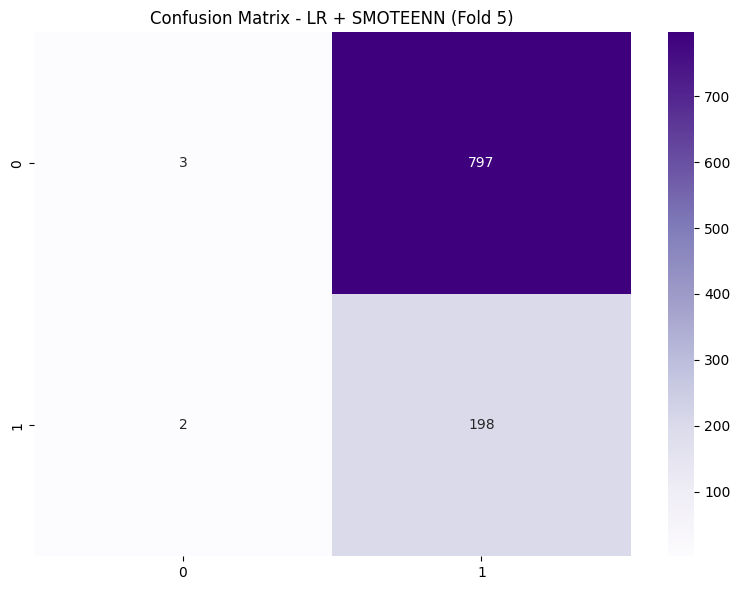

✓ Done: SMOTEENN


In [10]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('LR + SMOTEENN')
print("-" * 30)

best_model_lr_sme = None
best_score_lr_sme = 0
best_fold_idx_lr_sme = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # SMOTEENN
    sme = SMOTEENN(random_state=42)
    X_fold_train_res, y_fold_train_res = sme.fit_resample(X_fold_train, y_fold_train)
    
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_sme:
        best_score_lr_sme = score
        best_model_lr_sme = model
        best_fold_idx_lr_sme = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_sme}')
print("-" * 30)
y_pred = best_model_lr_sme.predict(X_test)
y_pred_proba = best_model_lr_sme.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + SMOTEENN - Fold {best_fold_idx_lr_sme})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + SMOTEENN (Fold {best_fold_idx_lr_sme})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_smoteenn.png', dpi=300)
plt.show()

lr_sme_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'SMOTEENN (Fold {best_fold_idx_lr_sme})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_sme, 'logistic_regression/models/LR_smoteenn_bestfold.pkl')
print("✓ Done: SMOTEENN")

------------------------------
LR + ADASYN + Tomek Links
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.5222
Fold 2: Val Accuracy = 0.5150


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 3: Val Accuracy = 0.5467
Fold 4: Val Accuracy = 0.5167


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.5261
------------------------------
>> Average CV Accuracy: 0.5253 (± 0.0114)
>> 🏆 Best Model Found in Fold: 3
------------------------------

TEST PERFORMANCE (LR + ADASYN + Tomek - Fold 3)
Accuracy:  0.5500
Recall:    0.4550
ROC-AUC:   0.4930


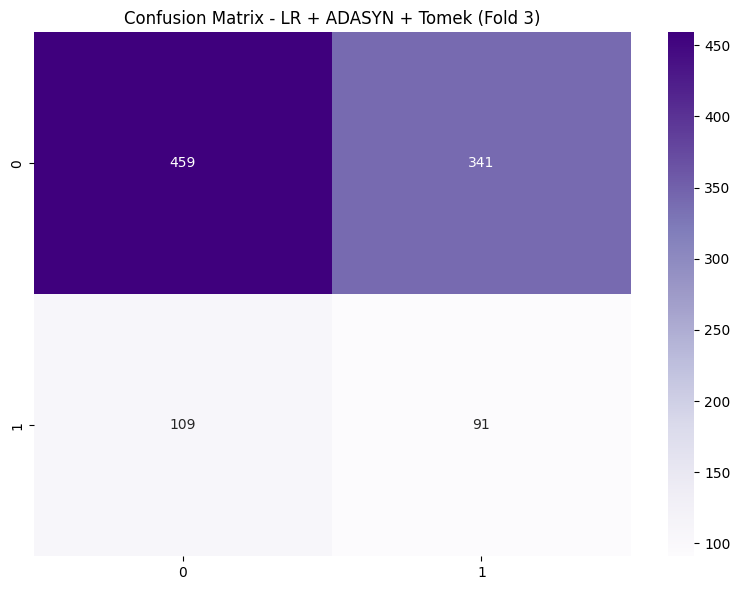

✓ Done: ADASYN + Tomek


In [11]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('LR + ADASYN + Tomek Links')
print("-" * 30)

best_model_lr_ada_tomek = None
best_score_lr_ada_tomek = 0
best_fold_idx_lr_ada_tomek = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Manual Pipeline: ADASYN -> Tomek
    ada = ADASYN(random_state=42)
    X_res, y_res = ada.fit_resample(X_fold_train, y_fold_train)
    tl = TomekLinks()
    X_fold_train_res, y_fold_train_res = tl.fit_resample(X_res, y_res)
    
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_ada_tomek:
        best_score_lr_ada_tomek = score
        best_model_lr_ada_tomek = model
        best_fold_idx_lr_ada_tomek = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_ada_tomek}')
print("-" * 30)
y_pred = best_model_lr_ada_tomek.predict(X_test)
y_pred_proba = best_model_lr_ada_tomek.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + ADASYN + Tomek - Fold {best_fold_idx_lr_ada_tomek})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + ADASYN + Tomek (Fold {best_fold_idx_lr_ada_tomek})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_adasyn_tomek.png', dpi=300)
plt.show()

lr_ada_tomek_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'ADASYN + Tomek (Fold {best_fold_idx_lr_ada_tomek})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_ada_tomek, 'logistic_regression/models/LR_adasyn_tomek_bestfold.pkl')
print("✓ Done: ADASYN + Tomek")

------------------------------
LR + Borderline2 + Tomek Links
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: Val Accuracy = 0.5511


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 2: Val Accuracy = 0.5439


...

Fold 3: Val Accuracy = 0.5717


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: Val Accuracy = 0.5300


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 5: Val Accuracy = 0.5344
------------------------------
>> Average CV Accuracy: 0.5462 (± 0.0147)
>> 🏆 Best Model Found in Fold: 3
------------------------------

TEST PERFORMANCE (LR + Borderline-2 + Tomek - Fold 3)
Accuracy:  0.5600
Recall:    0.3950
ROC-AUC:   0.4886


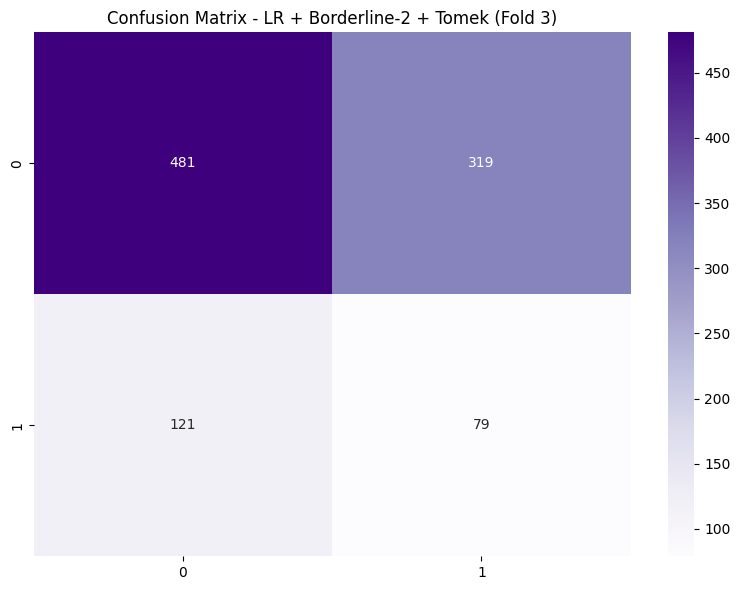

✓ Done: Borderline2 + Tomek


In [12]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('LR + Borderline2 + Tomek Links')
print("-" * 30)

best_model_lr_bl_tomek = None
best_score_lr_bl_tomek = 0
best_fold_idx_lr_bl_tomek = -1
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # Manual Pipeline: Borderline2 -> Tomek
    bl = BorderlineSMOTE(kind='borderline-2', random_state=42)
    X_res, y_res = bl.fit_resample(X_fold_train, y_fold_train)
    tl = TomekLinks()
    X_fold_train_res, y_fold_train_res = tl.fit_resample(X_res, y_res)
    
    model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
    model.fit(X_fold_train_res, y_fold_train_res)
    
    score = model.score(X_fold_val, y_fold_val)
    cv_scores.append(score)
    print(f"Fold {fold}: Val Accuracy = {score:.4f}")
    
    if score > best_score_lr_bl_tomek:
        best_score_lr_bl_tomek = score
        best_model_lr_bl_tomek = model
        best_fold_idx_lr_bl_tomek = fold
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_lr_bl_tomek}')
print("-" * 30)
y_pred = best_model_lr_bl_tomek.predict(X_test)
y_pred_proba = best_model_lr_bl_tomek.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"\nTEST PERFORMANCE (LR + Borderline-2 + Tomek - Fold {best_fold_idx_lr_bl_tomek})")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title(f'Confusion Matrix - LR + Borderline-2 + Tomek (Fold {best_fold_idx_lr_bl_tomek})')
plt.tight_layout()
os.makedirs('logistic_regression/models', exist_ok=True)
plt.savefig('logistic_regression/models/cm_lr_borderline2_tomek.png', dpi=300)
plt.show()

lr_bl_tomek_results = {
    'Model': 'Logistic Regression',
    'Sampling': f'Borderline-2 + Tomek (Fold {best_fold_idx_lr_bl_tomek})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}
joblib.dump(best_model_lr_bl_tomek, 'logistic_regression/models/LR_borderline2_tomek_bestfold.pkl')
print("✓ Done: Borderline2 + Tomek")

🏆 FINAL COMPARISON TABLE - Logistic Regression (Sorted by Recall)


,Model,Sampling,CV_Accuracy,CV_Std,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC,TP,TN,FP,FN
0,Logistic Regression,SMOTEENN (Fold 5),0.200333,0.000667,0.201,0.198995,0.990,0.331381,0.498606,198,3,797,2
1,Logistic Regression,NearMiss (Fold 2),0.492444,0.014413,0.493,0.210923,0.560,0.306430,0.528256,112,381,419,88
2,Logistic Regression,ADASYN (Fold 3),0.498222,0.011907,0.512,0.202479,0.490,0.286550,0.493912,98,414,386,102
3,Logistic Regression,RandomUnderSampler (Fold 2),0.505111,0.006753,0.494,0.194000,0.485,0.277143,0.478975,97,397,403,103
4,Logistic Regression,SMOTETomek (Fold 3),0.517667,0.003485,0.531,0.205689,0.470,0.286149,0.498650,94,437,363,106
5,Logistic Regression,SMOTE (Fold 1),0.516556,0.003341,0.525,0.201735,0.465,0.281392,0.486800,93,432,368,107
6,Logistic Regression,ClusterCentroids (Fold 2),0.509889,0.005527,0.525,0.200436,0.460,0.279211,0.494300,92,433,367,108
7,Logistic Regression,ADASYN + Tomek (Fold 3),0.525333,0.011378,0.550,0.210648,0.455,0.287975,0.492987,91,459,341,109
8,Logistic Regression,Borderline-2 + Tomek (Fold 3),0.546222,0.014688,0.560,0.198492,0.395,0.264214,0.488600,79,481,319,121
9,Logistic Regression,None (Baseline),0.800000,0.000000,0.800,0.000000,0.000,0.000000,0.491137,0,800,0,200


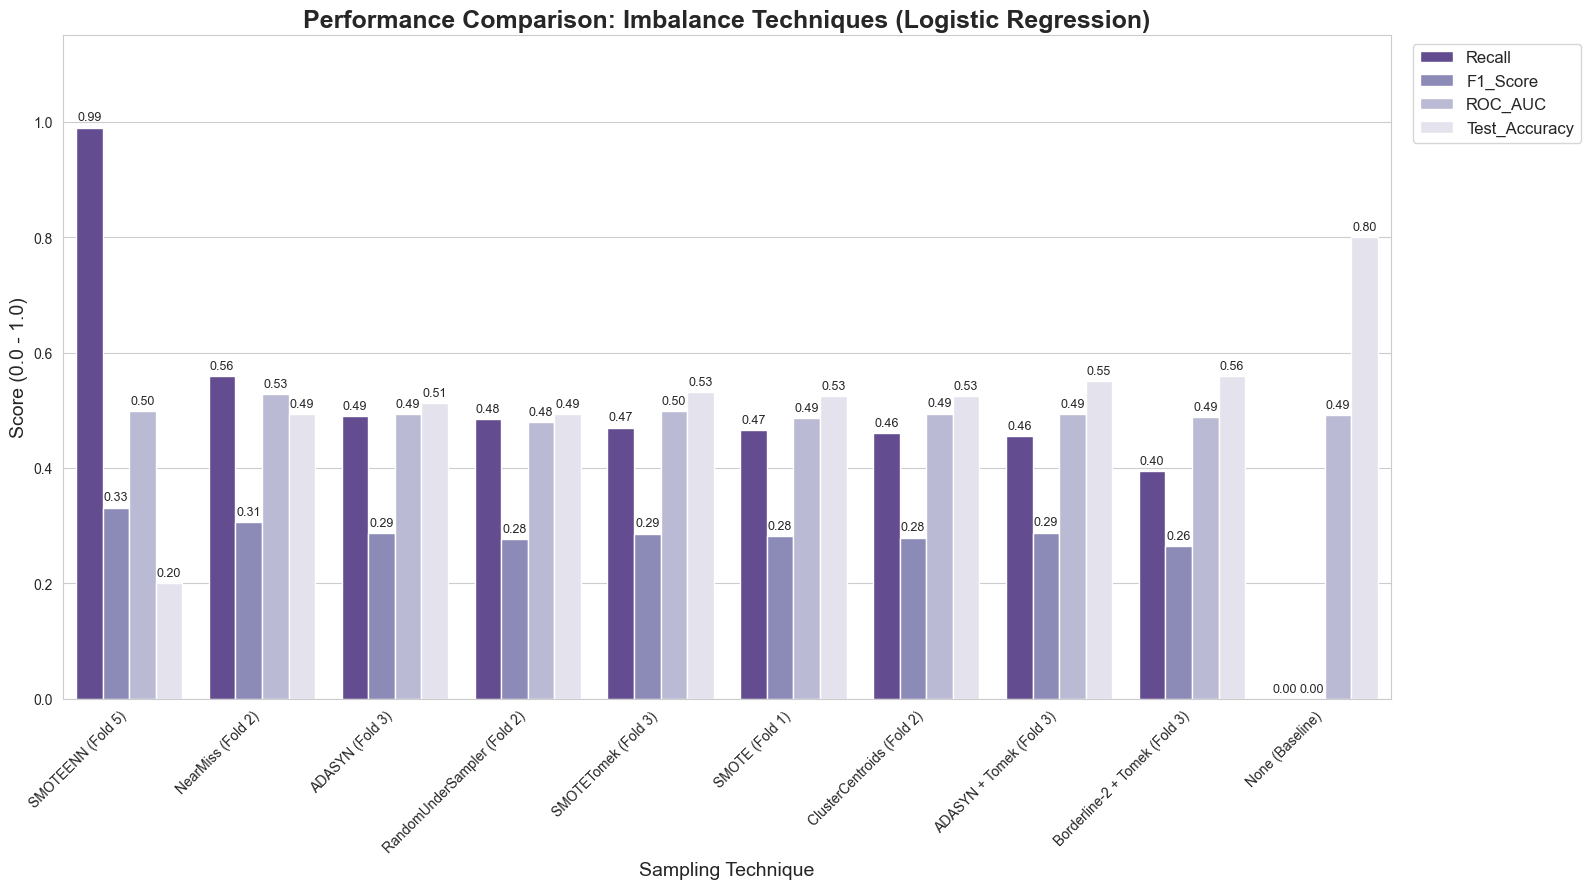

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

✓ Saved augmented results: logistic_regression/lr_technique_comparison_augmented.csv


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavi

,Model,Sampling,CV_Accuracy,CV_Std,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC,TP,...,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,CV_F1_Mean,CV_F1_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_PR_AUC_Mean,CV_PR_AUC_Std
0,Logistic Regression,SMOTEENN (Fold 5),0.200333,0.000667,0.201,0.198995,0.990,0.331381,0.498606,198,...,0.200067,0.000134,1.000000,0.000000,0.333426,0.000185,0.510819,0.014822,0.203863,0.006336
1,Logistic Regression,NearMiss (Fold 2),0.492444,0.014413,0.493,0.210923,0.560,0.306430,0.528256,112,...,0.203464,0.008336,0.528333,0.039729,0.293640,0.014246,0.502657,0.014892,0.201321,0.009267
2,Logistic Regression,ADASYN (Fold 3),0.498222,0.011907,0.512,0.202479,0.490,0.286550,0.493912,98,...,0.209980,0.005433,0.546667,0.031934,0.303301,0.009886,0.513138,0.014060,0.205384,0.010634
3,Logistic Regression,RandomUnderSampler (Fold 2),0.505111,0.006753,0.494,0.194000,0.485,0.277143,0.478975,97,...,0.206376,0.007296,0.518333,0.022125,0.295202,0.010955,0.513533,0.014125,0.205178,0.008332
4,Logistic Regression,SMOTETomek (Fold 3),0.517667,0.003485,0.531,0.205689,0.470,0.286149,0.498650,94,...,0.208282,0.007116,0.504444,0.026093,0.294809,0.011538,0.509905,0.015530,0.203318,0.007254
5,Logistic Regression,SMOTE (Fold 1),0.516556,0.003341,0.525,0.201735,0.465,0.281392,0.486800,93,...,0.207690,0.006237,0.503889,0.023740,0.294120,0.010232,0.509789,0.015637,0.203448,0.007388
6,Logistic Regression,ClusterCentroids (Fold 2),0.509889,0.005527,0.525,0.200436,0.460,0.279211,0.494300,92,...,0.201842,0.005347,0.491111,0.017338,0.286086,0.008155,0.508523,0.012901,0.203528,0.007297
7,Logistic Regression,ADASYN + Tomek (Fold 3),0.525333,0.011378,0.550,0.210648,0.455,0.287975,0.492987,91,...,0.208629,0.008657,0.491667,0.024658,0.292897,0.012325,0.512951,0.014081,0.205619,0.011260
8,Logistic Regression,Borderline-2 + Tomek (Fold 3),0.546222,0.014688,0.560,0.198492,0.395,0.264214,0.488600,79,...,0.205936,0.013579,0.443889,0.026954,0.281314,0.017821,0.511501,0.019130,0.205072,0.011474
9,Logistic Regression,None (Baseline),0.800000,0.000000,0.800,0.000000,0.000,0.000000,0.491137,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.512546,0.015391,0.205374,0.009954


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. รวมผลลัพธ์
lr_all_results = [
    lr_baseline_results,
    lr_smote_results,
    lr_adasyn_results,
    lr_rus_results,
    lr_nearmiss_results,
    lr_cc_results,
    lr_smt_results,
    lr_sme_results,
    lr_ada_tomek_results,
    lr_bl_tomek_results
]

# 2. แปลงเป็น DataFrame
df_lr_results = pd.DataFrame(lr_all_results)
df_lr_results = df_lr_results.sort_values(by='Recall', ascending=False).reset_index(drop=True)

# 3. แสดงตาราง
print("=" * 80)
print("🏆 FINAL COMPARISON TABLE - Logistic Regression (Sorted by Recall)")
print("=" * 80)
display(df_lr_results)

# 4. Save CSV
df_lr_results.to_csv('logistic_regression/lr_technique_comparison.csv', index=False)

# 5. Plot Graph
plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")
metrics_to_plot = ['Recall', 'F1_Score', 'ROC_AUC', 'Test_Accuracy']
df_melted = df_lr_results.melt(id_vars='Sampling', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

ax = sns.barplot(data=df_melted, x='Sampling', y='Score', hue='Metric', palette='Purples_r')
plt.title('Performance Comparison: Imbalance Techniques (Logistic Regression)', fontsize=18, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=14)
plt.xlabel('Sampling Technique', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
plt.ylim(0, 1.15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig('logistic_regression/models/lr_technique_comparison_chart.png', dpi=300)
plt.show()

# 6. Augment results with additional metrics (Specificity, Balanced Accuracy, Support, CV metrics)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss, ClusterCentroids, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.model_selection import cross_val_score

def _sampler_from_sampling_str(sampling_str):
    s = sampling_str.lower()
    if 'none' in s or 'baseline' in s:
        return None
    if 'smotetomek' in s or ('smote' in s and 'tomek' in s):
        return SMOTETomek(random_state=42)
    if 'smoteenn' in s or ('smote' in s and 'enn' in s):
        return SMOTEENN(random_state=42)
    if 'borderline' in s and 'tomek' in s:
        return 'borderline_tomek'
    if 'adasyn' in s and 'tomek' in s:
        return 'adasyn_tomek'
    if 'adasyn' in s:
        return ADASYN(random_state=42)
    if 'smote' in s:
        return SMOTE(random_state=42)
    if 'randomundersampler' in s or 'randomundersampler' in s.replace(' ', '') or 'undersampler' in s:
        return RandomUnderSampler(random_state=42)
    if 'nearmiss' in s:
        return NearMiss(version=1)
    if 'clustercentroids' in s or 'cluster' in s:
        return ClusterCentroids(random_state=42)
    return None

for idx, row in df_lr_results.iterrows():
    tn = row.get('TN', np.nan)
    fp = row.get('FP', np.nan)
    fn = row.get('FN', np.nan)
    tp = row.get('TP', np.nan)
    # Specificity
    spec = tn / (tn + fp) if (tn + fp) and not np.isnan(tn) and not np.isnan(fp) else np.nan
    # Balanced accuracy
    bal_acc = (row.get('Recall', np.nan) + spec) / 2 if not np.isnan(spec) else np.nan
    support_pos = int(tp + fn) if not np.isnan(tp) and not np.isnan(fn) else np.nan
    support_neg = int(tn + fp) if not np.isnan(tn) and not np.isnan(fp) else np.nan
    df_lr_results.loc[idx, 'Specificity'] = spec
    df_lr_results.loc[idx, 'Balanced_Acc'] = bal_acc
    df_lr_results.loc[idx, 'Support_Pos'] = support_pos
    df_lr_results.loc[idx, 'Support_Neg'] = support_neg

    # CV metrics using cross_val_score with an imblearn pipeline when appropriate
    sampling = row['Sampling']
    sampler = _sampler_from_sampling_str(sampling)
    if sampler == 'adasyn_tomek':
        steps = [('adasyn', ADASYN(random_state=42)), ('tomek', TomekLinks()), ('clf', LogisticRegression(random_state=42, max_iter=2000, solver='liblinear'))]
        pipe = ImbPipeline(steps)
    elif sampler == 'borderline_tomek':
        steps = [('bl', BorderlineSMOTE(kind='borderline-2', random_state=42)), ('tomek', TomekLinks()), ('clf', LogisticRegression(random_state=42, max_iter=2000, solver='liblinear'))]
        pipe = ImbPipeline(steps)
    else:
        if sampler is None:
            pipe = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
        else:
            pipe = ImbPipeline([('sampler', sampler), ('clf', LogisticRegression(random_state=42, max_iter=2000, solver='liblinear'))])

    scoring_map = {
        'precision': ('CV_Precision_Mean', 'CV_Precision_Std'),
        'recall': ('CV_Recall_Mean', 'CV_Recall_Std'),
        'f1': ('CV_F1_Mean', 'CV_F1_Std'),
        'roc_auc': ('CV_ROC_AUC_Mean', 'CV_ROC_AUC_Std'),
        'average_precision': ('CV_PR_AUC_Mean', 'CV_PR_AUC_Std')
    }

    for scoring_name, (mean_col, std_col) in scoring_map.items():
        try:
            scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=scoring_name, n_jobs=-1)
            df_lr_results.loc[idx, mean_col] = np.mean(scores)
            df_lr_results.loc[idx, std_col] = np.std(scores)
        except Exception:
            df_lr_results.loc[idx, mean_col] = np.nan
            df_lr_results.loc[idx, std_col] = np.nan

# Save augmented CSV
df_lr_results.to_csv('logistic_regression/lr_technique_comparison_augmented.csv', index=False)
print('✓ Saved augmented results: logistic_regression/lr_technique_comparison_augmented.csv')
display(df_lr_results)